# Realistic Connectome CPM: Trait Anxiety, Insula–DMN Signal

This notebook is the next step after the basic CPM notebook.

It still uses **simulated data**, but the simulation is more neuroscience-like:

- Subjects have a continuous **trait anxiety score**
- Each subject has an ROI × ROI **functional connectivity matrix**
- ROIs are labeled by network: DMN, salience network, CEN/FPN, sensory/motor/other
- A hidden anxiety-related signal is injected mainly into **anterior insula ↔ DMN edges**
- CPM is then used to test whether connectivity predicts trait anxiety in unseen subjects

This is a teaching notebook: it helps you understand what CPM is doing before replacing simulated matrices with real HCP/OpenNeuro/UK Biobank connectomes.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

for d in [PROCESSED_DIR, PHENO_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Phenotypes:", PHENO_DIR)
print("Results:", RESULTS_DIR)
print("Figures:", FIGURES_DIR)

Project root: /home/john-walkey/Data/Research/connectome
Processed data: /home/john-walkey/Data/Research/connectome/data/processed
Phenotypes: /home/john-walkey/Data/Research/connectome/data/phenotypes
Results: /home/john-walkey/Data/Research/connectome/results
Figures: /home/john-walkey/Data/Research/connectome/figures


## 1. Imports and project folders

This assumes your notebook is inside:

```text
~/Data/Research/connectome/notebooks/
```

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

# If this notebook is in connectome/notebooks, parent is the project root
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

for d in [RAW_DIR, PROCESSED_DIR, PHENO_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results will be saved to:", RESULTS_DIR)
print("Figures will be saved to:", FIGURES_DIR)

Project root: /home/john-walkey/Data/Research/connectome
Results will be saved to: /home/john-walkey/Data/Research/connectome/results
Figures will be saved to: /home/john-walkey/Data/Research/connectome/figures


## 2. Define a realistic ROI list

For now, we make a small atlas-like table. Later, this can be replaced with a real atlas such as Schaefer, Harvard-Oxford, Power, or a custom insula + DMN + CEN ROI set.

In [3]:
roi_table = pd.DataFrame({
    "roi": [
        "mPFC", "PCC", "Left Angular", "Right Angular", "Left Hippocampus", "Right Hippocampus",
        "Left Anterior Insula", "Right Anterior Insula", "dACC",
        "Left dlPFC", "Right dlPFC", "Left IPS", "Right IPS",
        "Left Visual", "Right Visual", "Left Auditory", "Right Auditory",
        "Left Motor", "Right Motor", "Cerebellum"
    ],
    "network": [
        "DMN", "DMN", "DMN", "DMN", "DMN", "DMN",
        "SN", "SN", "SN",
        "CEN", "CEN", "CEN", "CEN",
        "Sensory", "Sensory", "Sensory", "Sensory",
        "Motor", "Motor", "Other"
    ]
})

n_rois = len(roi_table)
roi_table

,roi,network
0,mPFC,DMN
1,PCC,DMN
2,Left Angular,DMN
3,Right Angular,DMN
4,Left Hippocampus,DMN
5,Right Hippocampus,DMN
6,Left Anterior Insula,SN
7,Right Anterior Insula,SN
8,dACC,SN
9,Left dlPFC,CEN


## 3. Simulate subjects and trait anxiety scores

Think of this as a stand-in for a phenotype file:

```text
subject_id, trait_anxiety
sub-001, 42
sub-002, 55
...
```

In [4]:
rng = np.random.default_rng(42)

n_subjects = 80  # larger than 24 so the CPM demonstration is stable
subject_ids = [f"sub-{i:03d}" for i in range(1, n_subjects + 1)]

# STAI-like range: roughly 20 to 80
trait_anxiety = rng.normal(loc=45, scale=10, size=n_subjects)
trait_anxiety = np.clip(trait_anxiety, 20, 80)

phenotypes = pd.DataFrame({
    "subject_id": subject_ids,
    "trait_anxiety": trait_anxiety
})

phenotypes.to_csv(PHENO_DIR / "simulated_trait_anxiety.csv", index=False)
phenotypes.head()

,subject_id,trait_anxiety
0,sub-001,48.047171
1,sub-002,34.600159
2,sub-003,52.504512
3,sub-004,54.405647
4,sub-005,25.489648


## 4. Simulate functional connectomes

Each subject gets a symmetric ROI × ROI connectivity matrix.

The hidden signal is:

> higher trait anxiety → stronger connectivity between anterior insula and DMN nodes

That matches your working hypothesis:

> altered insula–DMN coupling may relate to trait anxiety / internally oriented attention.

In [5]:
def make_symmetric_matrix(n_rois, rng, base_sd=0.15):
    """Create one random symmetric functional connectivity matrix."""
    mat = rng.normal(0, base_sd, size=(n_rois, n_rois))
    mat = (mat + mat.T) / 2
    np.fill_diagonal(mat, 1.0)
    return mat

# ROI indices
dmn_idx = roi_table.index[roi_table["network"] == "DMN"].to_numpy()
insula_idx = roi_table.index[roi_table["roi"].str.contains("Anterior Insula")].to_numpy()
cen_idx = roi_table.index[roi_table["network"] == "CEN"].to_numpy()
sn_idx = roi_table.index[roi_table["network"] == "SN"].to_numpy()

# Standardize anxiety for injecting signal
anxiety_z = (trait_anxiety - trait_anxiety.mean()) / trait_anxiety.std()

connectomes = np.zeros((n_subjects, n_rois, n_rois))

for s in range(n_subjects):
    mat = make_symmetric_matrix(n_rois, rng)

    # Add shared network structure: within-network edges slightly positive
    for group in [dmn_idx, sn_idx, cen_idx]:
        for i in group:
            for j in group:
                if i < j:
                    mat[i, j] += 0.12
                    mat[j, i] += 0.12

    # Inject trait-anxiety signal into insula-DMN edges
    for i in insula_idx:
        for j in dmn_idx:
            signal = 0.18 * anxiety_z[s]
            mat[i, j] += signal
            mat[j, i] += signal

    mat = np.clip(mat, -0.8, 0.8)
    np.fill_diagonal(mat, 1.0)
    connectomes[s] = mat

np.save(PROCESSED_DIR / "simulated_connectomes.npy", connectomes)
print("Connectomes shape:", connectomes.shape)

Connectomes shape: (80, 20, 20)


## 5. Visualize one subject's connectome

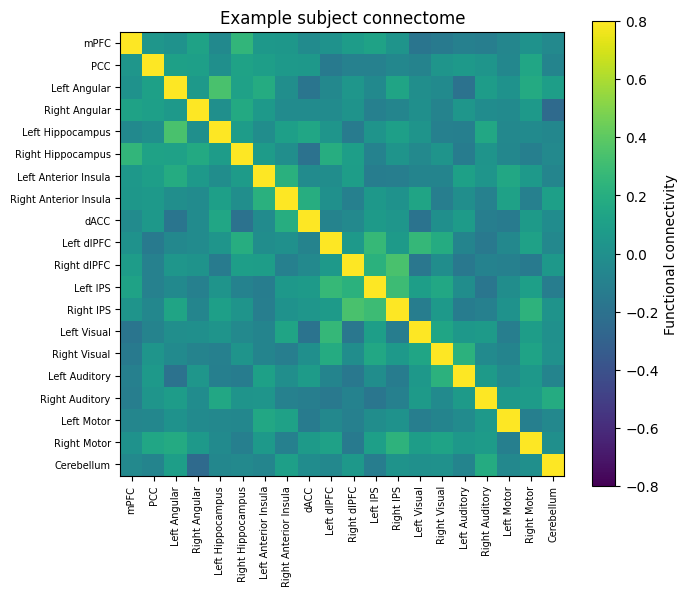

In [6]:
plt.figure(figsize=(7, 6))
plt.imshow(connectomes[0], vmin=-0.8, vmax=0.8)
plt.colorbar(label="Functional connectivity")
plt.xticks(range(n_rois), roi_table["roi"], rotation=90, fontsize=7)
plt.yticks(range(n_rois), roi_table["roi"], fontsize=7)
plt.title("Example subject connectome")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "example_subject_connectome.png", dpi=200)
plt.show()

## 6. Convert connectomes into CPM features

A connectome matrix is symmetric, so the lower triangle duplicates the upper triangle.

CPM usually vectorizes only the upper triangle. Each edge becomes one feature.

In [7]:
def vectorize_upper_triangle(connectomes):
    """Convert subject × ROI × ROI matrices into subject × edge feature matrix."""
    n_subjects, n_rois, _ = connectomes.shape
    iu = np.triu_indices(n_rois, k=1)
    X = connectomes[:, iu[0], iu[1]]
    return X, iu

X, edge_indices = vectorize_upper_triangle(connectomes)
y = phenotypes["trait_anxiety"].to_numpy()

print("Subjects:", X.shape[0])
print("Edges/features:", X.shape[1])

Subjects: 80
Edges/features: 190


## 7. Define CPM functions

Core CPM logic:

1. In the **training data only**, correlate each edge with trait anxiety
2. Select edges related to the target variable
3. Sum selected positive edges and selected negative edges
4. Fit a simple regression model
5. Predict the held-out subjects

Important: feature selection must happen **inside each training fold**, not on the full dataset.

In [8]:
def select_cpm_edges(X_train, y_train, p_threshold=0.01):
    """Select positive and negative edges in training data only."""
    n_edges = X_train.shape[1]
    r_vals = np.zeros(n_edges)
    p_vals = np.ones(n_edges)

    for e in range(n_edges):
        r, p = pearsonr(X_train[:, e], y_train)
        r_vals[e] = r
        p_vals[e] = p

    pos_mask = (r_vals > 0) & (p_vals < p_threshold)
    neg_mask = (r_vals < 0) & (p_vals < p_threshold)

    return pos_mask, neg_mask, r_vals, p_vals


def summarize_network_strength(X, pos_mask, neg_mask):
    """Create CPM summary features: sum of selected positive and negative edges."""
    pos_strength = X[:, pos_mask].sum(axis=1) if pos_mask.sum() > 0 else np.zeros(X.shape[0])
    neg_strength = X[:, neg_mask].sum(axis=1) if neg_mask.sum() > 0 else np.zeros(X.shape[0])
    return np.column_stack([pos_strength, neg_strength])


def run_cpm_kfold(X, y, n_splits=5, p_threshold=0.01, random_state=42):
    """Run k-fold CPM and return predictions plus fold details."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_pred = np.zeros_like(y, dtype=float)
    fold_info = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]

        pos_mask, neg_mask, r_vals, p_vals = select_cpm_edges(
            X_train, y_train, p_threshold=p_threshold
        )

        X_train_summary = summarize_network_strength(X_train, pos_mask, neg_mask)
        X_test_summary = summarize_network_strength(X_test, pos_mask, neg_mask)

        model = LinearRegression()
        model.fit(X_train_summary, y_train)
        y_pred[test_idx] = model.predict(X_test_summary)

        fold_info.append({
            "fold": fold,
            "n_pos_edges": int(pos_mask.sum()),
            "n_neg_edges": int(neg_mask.sum()),
            "pos_mask": pos_mask,
            "neg_mask": neg_mask
        })

    return y_pred, fold_info

## 8. Run CPM

This is where the machine-learning / prediction part happens.

In [9]:
y_pred, fold_info = run_cpm_kfold(
    X, y,
    n_splits=5,
    p_threshold=0.01,
    random_state=42
)

r, p = pearsonr(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Predicted vs actual correlation r = {r:.3f}, p = {p:.4f}")
print(f"MAE = {mae:.2f} anxiety-score points")
print(f"RMSE = {rmse:.2f} anxiety-score points")
print("Average selected positive edges:", np.mean([f["n_pos_edges"] for f in fold_info]))
print("Average selected negative edges:", np.mean([f["n_neg_edges"] for f in fold_info]))

Predicted vs actual correlation r = 0.985, p = 0.0000
MAE = 1.09 anxiety-score points
RMSE = 1.36 anxiety-score points
Average selected positive edges: 13.0
Average selected negative edges: 1.0


## 9. Plot predicted vs actual anxiety

This is the main CPM performance plot.

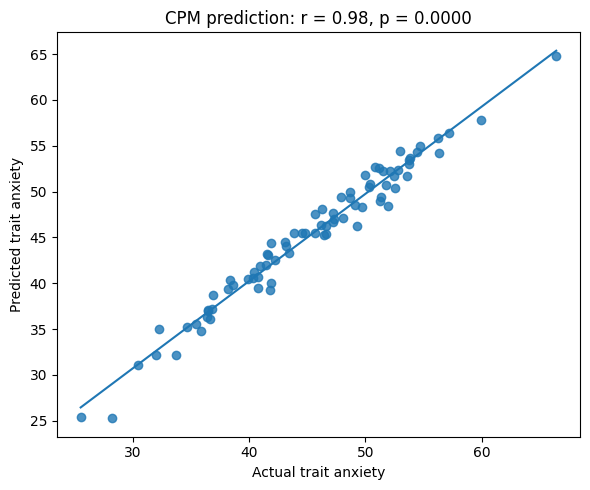

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, alpha=0.8)
plt.xlabel("Actual trait anxiety")
plt.ylabel("Predicted trait anxiety")
plt.title(f"CPM prediction: r = {r:.2f}, p = {p:.4f}")

coef = np.polyfit(y, y_pred, deg=1)
x_line = np.linspace(y.min(), y.max(), 100)
plt.plot(x_line, coef[0] * x_line + coef[1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cpm_predicted_vs_actual_trait_anxiety.png", dpi=200)
plt.show()

## 10. Which edges did CPM select?

Because this is simulated, we know the true signal was planted mostly in **insula ↔ DMN** edges.

In real data, this step becomes interpretation:

> Are selected predictive edges located in theoretically meaningful networks?

In [11]:
def edge_table_from_masks(edge_indices, fold_info, roi_table):
    """Create a table showing how often each edge was selected across folds."""
    i_idx, j_idx = edge_indices
    rows = []

    for e, (i, j) in enumerate(zip(i_idx, j_idx)):
        pos_count = sum(f["pos_mask"][e] for f in fold_info)
        neg_count = sum(f["neg_mask"][e] for f in fold_info)

        rows.append({
            "edge": e,
            "roi_i": roi_table.loc[i, "roi"],
            "roi_j": roi_table.loc[j, "roi"],
            "network_i": roi_table.loc[i, "network"],
            "network_j": roi_table.loc[j, "network"],
            "pos_selected_folds": pos_count,
            "neg_selected_folds": neg_count,
            "total_selected_folds": pos_count + neg_count
        })

    return pd.DataFrame(rows)

selected_edges = edge_table_from_masks(edge_indices, fold_info, roi_table)
selected_edges_sorted = selected_edges.sort_values(
    ["total_selected_folds", "pos_selected_folds"], ascending=False
)

selected_edges_sorted.head(20)

,edge,roi_i,roi_j,network_i,network_j,pos_selected_folds,neg_selected_folds,total_selected_folds
5,5,mPFC,Left Anterior Insula,DMN,SN,5,0,5
6,6,mPFC,Right Anterior Insula,DMN,SN,5,0,5
23,23,PCC,Left Anterior Insula,DMN,SN,5,0,5
24,24,PCC,Right Anterior Insula,DMN,SN,5,0,5
40,40,Left Angular,Left Anterior Insula,DMN,SN,5,0,5
41,41,Left Angular,Right Anterior Insula,DMN,SN,5,0,5
56,56,Right Angular,Left Anterior Insula,DMN,SN,5,0,5
57,57,Right Angular,Right Anterior Insula,DMN,SN,5,0,5
71,71,Left Hippocampus,Left Anterior Insula,DMN,SN,5,0,5
72,72,Left Hippocampus,Right Anterior Insula,DMN,SN,5,0,5


In [12]:
selected_edges_sorted.to_csv(RESULTS_DIR / "selected_cpm_edges.csv", index=False)
print("Saved edge table to:", RESULTS_DIR / "selected_cpm_edges.csv")

Saved edge table to: /home/john-walkey/Data/Research/connectome/results/selected_cpm_edges.csv


## 11. Count selected edges by network pair

This makes the result easier to interpret.

In [13]:
edge_counts = (
    selected_edges
    .query("total_selected_folds > 0")
    .assign(
        network_pair=lambda df: df.apply(
            lambda row: " - ".join(sorted([row["network_i"], row["network_j"]])),
            axis=1
        )
    )
    .groupby("network_pair")["total_selected_folds"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

edge_counts

,network_pair,total_selected_folds
0,DMN - SN,60
1,CEN - DMN,3
2,DMN - DMN,3
3,Sensory - Sensory,2
4,CEN - Other,1
5,DMN - Other,1


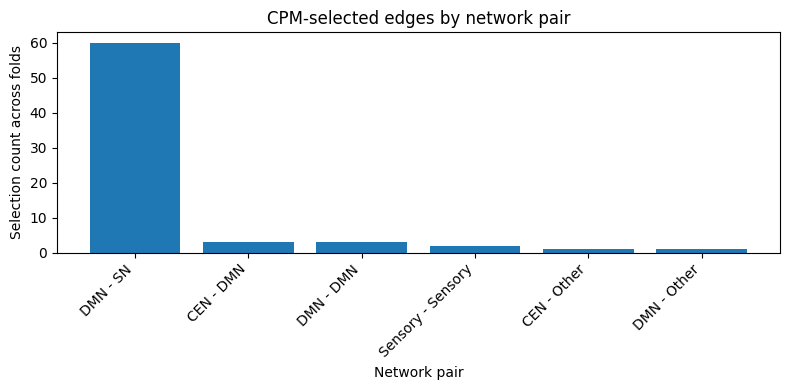

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(edge_counts["network_pair"], edge_counts["total_selected_folds"])
plt.ylabel("Selection count across folds")
plt.xlabel("Network pair")
plt.title("CPM-selected edges by network pair")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "selected_edges_by_network_pair.png", dpi=200)
plt.show()

## 12. Specifically inspect insula–DMN edges

This is your theoretical target.

In the simulation, these edges carry the planted signal. CPM should often select them.

In [15]:
insula_dmn_edges = selected_edges[
    (
        selected_edges["roi_i"].str.contains("Insula") & (selected_edges["network_j"] == "DMN")
    ) |
    (
        selected_edges["roi_j"].str.contains("Insula") & (selected_edges["network_i"] == "DMN")
    )
].sort_values("total_selected_folds", ascending=False)

insula_dmn_edges

,edge,roi_i,roi_j,network_i,network_j,pos_selected_folds,neg_selected_folds,total_selected_folds
5,5,mPFC,Left Anterior Insula,DMN,SN,5,0,5
6,6,mPFC,Right Anterior Insula,DMN,SN,5,0,5
23,23,PCC,Left Anterior Insula,DMN,SN,5,0,5
24,24,PCC,Right Anterior Insula,DMN,SN,5,0,5
40,40,Left Angular,Left Anterior Insula,DMN,SN,5,0,5
41,41,Left Angular,Right Anterior Insula,DMN,SN,5,0,5
56,56,Right Angular,Left Anterior Insula,DMN,SN,5,0,5
57,57,Right Angular,Right Anterior Insula,DMN,SN,5,0,5
71,71,Left Hippocampus,Left Anterior Insula,DMN,SN,5,0,5
72,72,Left Hippocampus,Right Anterior Insula,DMN,SN,5,0,5


In [16]:
insula_dmn_edges.to_csv(RESULTS_DIR / "insula_dmn_selected_edges.csv", index=False)
print("Saved insula-DMN edge table to:", RESULTS_DIR / "insula_dmn_selected_edges.csv")

Saved insula-DMN edge table to: /home/john-walkey/Data/Research/connectome/results/insula_dmn_selected_edges.csv


## 13. Save predictions

This creates a CSV with actual and predicted anxiety scores.

In [17]:
predictions = phenotypes.copy()
predictions["predicted_trait_anxiety"] = y_pred
predictions["prediction_error"] = predictions["predicted_trait_anxiety"] - predictions["trait_anxiety"]

predictions.to_csv(RESULTS_DIR / "cpm_trait_anxiety_predictions.csv", index=False)
predictions.head()

,subject_id,trait_anxiety,predicted_trait_anxiety,prediction_error
0,sub-001,48.047171,47.156466,-0.890704
1,sub-002,34.600159,35.190728,0.590569
2,sub-003,52.504512,50.380495,-2.124017
3,sub-004,54.405647,54.271999,-0.133648
4,sub-005,25.489648,25.466716,-0.022932


## 14. What this notebook shows

This notebook demonstrates the logic you can explain to a PI:

> We create one connectome per subject, use cross-validation to learn which edges predict trait anxiety in the training subjects, then test whether those edges predict anxiety in unseen subjects.

For your actual PhD idea, the real-data version would replace the simulated arrays with:

```text
data/processed/real_connectomes.npy
data/phenotypes/real_trait_anxiety.csv
```

Then the same CPM logic can be reused.

## 15. Next real-data step

To move from this teaching notebook to real fMRI data:

1. Identify a dataset with fMRI and trait anxiety or related phenotype
2. Preprocess or obtain preprocessed fMRI
3. Extract ROI time series using an atlas
4. Compute ROI × ROI correlations per subject
5. Save:
   - `data/processed/connectomes.npy`
   - `data/phenotypes/trait_anxiety.csv`
6. Run CPM using the same code above